# Task
    
Write a Python code to fit a straight line y = ax+b to an experimental dataset employing a Bayesian Markov Chain Monte Carlo (MCMC) sampler using the Metropolis-Hastings algorithm. 

The desired distribution is $\sim \mathcal{P}_{prior} \times e^{-1/2 \chi^2}$ where $$\chi^2 = \sum_i (\frac{y_{theo,i} - y_{exp,i}}{\sigma_i})^2.$$

Implementing both uniform and Gaussian form for prior distribution.

## Imports

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import io

## DS load

In [64]:
data = """0.1 0.20 0.02
0.2 0.38 0.03
0.3 0.62 0.04
0.4 0.81 0.02
"""

ds = pd.read_csv(io.StringIO(data), sep=r"\s+", header=None, names=["x", "y", "y_err"])
ds

,x,y,y_err
0,0.1,0.20,0.02
1,0.2,0.38,0.03
2,0.3,0.62,0.04
3,0.4,0.81,0.02


In [65]:
def plot_points(x, y, a=None, b=None, chain=None):
    if chain is not None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))
        ax2 = None

    ax1.scatter(x, y, label="data", color="black")
    if a is not None and b is not None:
        ax1.axline(
            xy1=(0, b), slope=a, color="red", label="predicted", linestyle="--"
        )
    ax1.legend()

    if ax2 is not None and chain is not None:
        ax2.hist(chain[:, 0], bins=30, alpha=0.5, label="a")
        ax2.hist(chain[:, 1], bins=30, alpha=0.5, label="b")
        ax2.legend()

    plt.show()

## Functions

In [67]:
import numpy as np


def ln_prior(a, b, prior_type="uniform"):
    if prior_type == "uniform":
        if -100.0 < a < 100.0 and -100.0 < b < 100.0:
            return 0.0
        return -np.inf

    elif prior_type == "gaussian":
        mu, sigma = 0.0, 10.0
        ln_p_a = -0.5 * ((a - mu) / sigma) ** 2
        ln_p_b = -0.5 * ((b - mu) / sigma) ** 2
        return ln_p_a + ln_p_b

    return -np.inf

In [68]:
def ln_desired_distribution(a, b, x_data, y_data, err_data, prior_type="uniform"):
    lp = ln_prior(a, b, prior_type)

    if not np.isfinite(lp):
        return -np.inf

    y_theo = a * x_data + b
    chi2 = np.sum(((y_theo - y_data) / err_data) ** 2)

    return lp - 0.5 * chi2

## MCMC Hastings

In [69]:
def metropolis_hastings(x_data, y_data, err_data, num_steps=50000, prior_type="uniform"):
    current_theta = np.array([0.0, 0.0])

    current_log_prob = ln_desired_distribution(current_theta[0],current_theta[1],x_data,y_data,err_data,prior_type)

    step_size = np.array([0.05, 0.05])

    chain = np.zeros((num_steps, 2))

    accepted_steps = 0

    for i in range(num_steps):
        proposal_theta = current_theta + np.random.normal(0, step_size)

        proposal_log_prob = ln_desired_distribution(proposal_theta[0], proposal_theta[1], x_data, y_data, err_data, prior_type)

        # it is a the same as division of probs, but we have logs
        log_acceptance_ratio = proposal_log_prob - current_log_prob

        # if log_acceptence > 0 => accept
        # if log_acceptence < ratio => random num and log(u) < ratio
        if log_acceptance_ratio > 0 or np.log(np.random.uniform(0, 1)) < log_acceptance_ratio:
            current_theta = proposal_theta
            current_log_prob = proposal_log_prob
            accepted_steps += 1

        chain[i] = current_theta

    print(f"Finished! Acceptance rate ({prior_type} prior): {accepted_steps / num_steps * 100:.1f}%")
    return chain

## Testing

In [70]:
x_exp = ds["x"].to_numpy()
y_exp = ds["y"].to_numpy()
sigma = ds["y_err"].to_numpy()

N_STEPS = 50000
burn_in = int(0.2 * N_STEPS)

chain_uni = metropolis_hastings(x_exp, y_exp, sigma, num_steps=N_STEPS, prior_type="uniform")[burn_in:]
chain_gauss = metropolis_hastings(x_exp, y_exp, sigma, num_steps=N_STEPS, prior_type="gaussian")[burn_in:]

a_uni, b_uni = np.mean(chain_uni[:, 0]), np.mean(chain_uni[:, 1])
a_gauss, b_gauss = np.mean(chain_gauss[:, 0]), np.mean(chain_gauss[:, 1])

print("\n=== WYNIKI KOŃCOWE ===")
print(f"Uniform Prior : y = {a_uni:.3f}*x + {b_uni:.3f}  (± a:{np.std(chain_uni[:,0]):.3f}, b:{np.std(chain_uni[:,1]):.3f})")
print(f"Gaussian Prior: y = {a_gauss:.3f}*x + {b_gauss:.3f} (± a:{np.std(chain_gauss[:,0]):.3f}, b:{np.std(chain_gauss[:,1]):.3f})")

Finished! Acceptance rate (uniform prior): 26.1%
Finished! Acceptance rate (gaussian prior): 26.1%

=== WYNIKI KOŃCOWE ===
Uniform Prior : y = 2.046*x + -0.009  (± a:0.091, b:0.026)
Gaussian Prior: y = 2.054*x + -0.011 (± a:0.091, b:0.025)


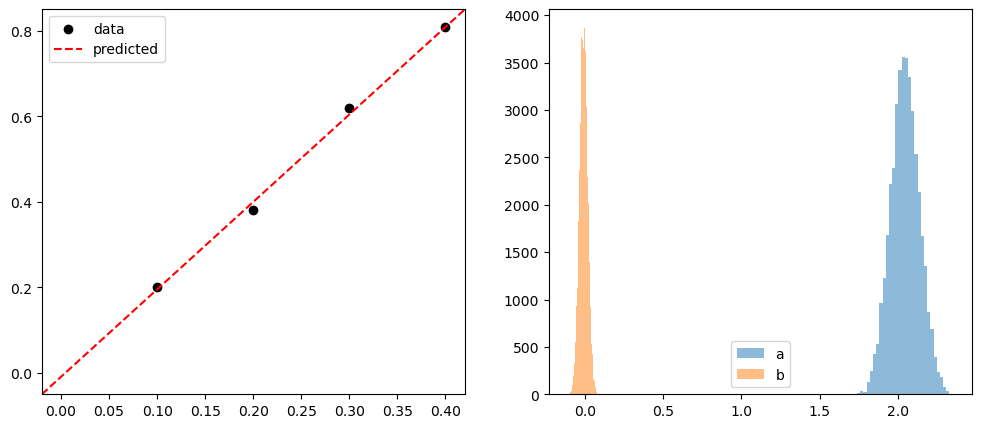

In [71]:
plot_points(ds['x'],ds['y'], a=a_uni, b=b_uni, chain=chain_uni)

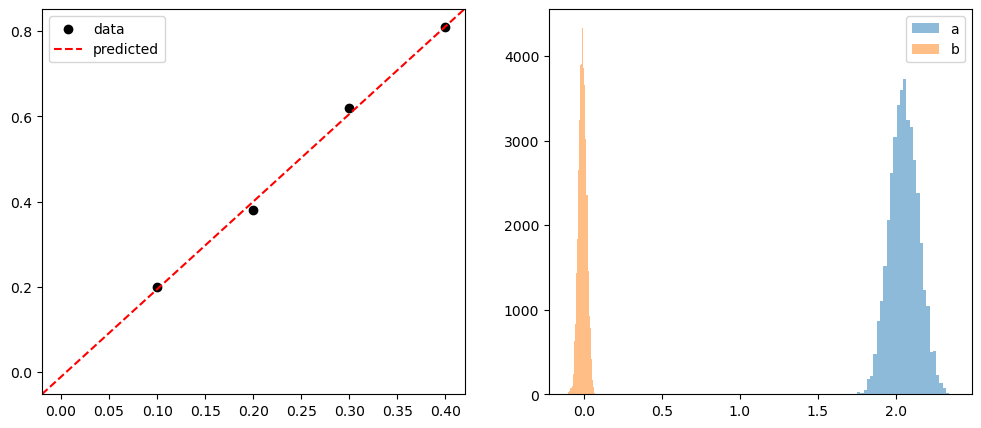

In [72]:
plot_points(ds['x'],ds['y'], a=a_gauss, b=b_gauss, chain=chain_gauss)

# Summary

## Report: Linear Regression using MCMC Metropolis-Hastings Algorithm

### 1. Introduction and Problem Statement
The objective of this assignment was to fit a straight line defined by the equation $y = ax + b$ to an experimental dataset, accounting for measurement uncertainties $\sigma_i$. Instead of employing a classical deterministic optimization method (such as the Ordinary Least Squares), a Bayesian approach utilizing Markov Chain Monte Carlo (MCMC) sampling via the Metropolis-Hastings algorithm was implemented.

The target distribution (*posterior* probability) is defined as follows:
$$\mathcal{P}_{posterior} \sim \mathcal{P}_{prior} \times e^{-\frac{1}{2}\chi^2}$$

Where the likelihood function is based on the $\chi^2$ (chi-squared) statistic:
$$\chi^2 = \sum_i \left(\frac{y_{theo,i} - y_{exp,i}}{\sigma_i}\right)^2$$

Two distinct types of prior distributions ($\mathcal{P}_{prior}$) were implemented and evaluated: a Uniform prior and a Gaussian prior.

---

### 2. Methodology and Algorithm Implementation

#### Logarithmic Scale Implementation
For numerical stability and to mitigate the risk of arithmetic underflow (where the exponential term becomes too close to zero), all probability calculations were performed in the natural logarithm ($\ln$) domain. Operating in log-space transforms the multiplication of distributions into a straightforward addition:
$$\ln(\mathcal{P}_{posterior}) = \ln(\mathcal{P}_{prior}) - \frac{1}{2}\chi^2$$

#### Steps of the Metropolis-Hastings Algorithm:
1. **Initialization:** The algorithm initializes the parameter vector at a starting point $\theta_{old} = [a=0, b=0]$.
2. **Proposal Generation:** In each iteration, a new candidate parameter vector $\theta_{new}$ is proposed by adding random noise drawn from a normal distribution (centered at 0 with a predefined `step_size`) to the current state.
3. **Acceptance Criterion:** The decision to transition to the proposed state is determined by the log-acceptance ratio:
   $$\Delta \ln \mathcal{P} = \ln(\mathcal{P}_{new}) - \ln(\mathcal{P}_{old})$$
   * If $\Delta \ln \mathcal{P} > 0$ (the proposed state has a higher probability), the step is accepted unconditionally.
   * If $\Delta \ln \mathcal{P} \le 0$, the step is accepted conditionally with a probability of $P = e^{\Delta \ln \mathcal{P}}$. This is evaluated by drawing a random variable $u \sim \mathcal{U}(0,1)$ and checking if $\ln(u) < \Delta \ln \mathcal{P}$.
4. **Recording and Iteration:** The state of the system (either the newly accepted parameters or the retained current parameters if rejected) is appended to the chain. This process is repeated for $N = 50,000$ iterations.

---

### 3. Statistical Analysis and Burn-in
The initial 20% of the generated Markov chain steps were discarded as the *burn-in* phase. This procedure is crucial because the initial iterations reflect the transient period during which the sampler moves from an arbitrary starting location toward the high-probability region. Including these steps would bias the final statistics. The ultimate estimates for parameters $a$ and $b$ were calculated as the arithmetic mean of the post-burn-in chain, while their respective uncertainties were derived from the standard deviation.

---

### 4. Discussion of Priors and Conclusion

* **Uniform Prior:** Adopting a wide uniform prior represents a state of complete prior ignorance regarding the model parameters. Under this assumption, the shape of the posterior distribution is driven entirely by the experimental data (the likelihood function).
* **Gaussian Prior:** Incorporating a Gaussian prior allows the integration of prior knowledge (e.g., historical data or physical constraints) indicating that the parameters are expected to lie near a specific mean value. In datasets with limited data points, this prior acts as a regularizer, penalizing extreme values and yielding narrower, more constrained posterior distributions on the final histograms.

The implemented MCMC Metropolis-Hastings sampler successfully determined the optimal regression line parameters for both prior configurations, while naturally providing robust standard error estimates directly derived from the posterior probability density.